In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 38.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 100.5 MB/s eta 0:00:0000:01
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-st

In [2]:
from roboflow import Roboflow

# Store your API key in a variable (do NOT print it if you want to keep it secret)
robo_key = "iNqY8TjGSKAmKupTyEIE"

# Initialize Roboflow
rf = Roboflow(api_key=robo_key)

# Access the workspace and project using their slugs/IDs
project = rf.workspace("sayed-gamall").project("fire-smoke-detection-yolov11")
version = project.version(2)

# Download the dataset in YOLOv11 format
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fire-Smoke-Detection-Yolov11-2 in yolov11:: 100%|██████████| 20938/20938 [00:02<00:00, 8218.04it/s] 


In [7]:
import os
from pathlib import Path

# Adjust this to your actual Roboflow folder name in Colab
source_dir = Path("/kaggle/working/Fire-Smoke-Detection-Yolov11-2") 

def analyze_dataset(path):
    train_labels = path / "train" / "labels"
    files = os.listdir(train_labels)
    
    stats = {}
    for f in files:
        with open(train_labels / f, 'r') as file:
            for line in file:
                cls = line.split()[0]
                stats[cls] = stats.get(cls, 0) + 1
    
    print(f"Total Label Files: {len(files)}")
    print(f"Objects found per Class ID: {stats}")
    # Class 0 usually = Fire, Class 1 usually = Smoke

analyze_dataset(source_dir)

Total Label Files: 9156
Objects found per Class ID: {'0': 11505, '1': 4312}


In [8]:
import shutil, random, cv2

mini_dir = Path("/kaggle/working/mini_data")
if mini_dir.exists(): shutil.rmtree(mini_dir)

# Create structure
for split in ['train', 'val']:
    for folder in ['images', 'labels']:
        os.makedirs(mini_dir / split / folder, exist_ok=True)

def build_mini_set(source, n_fire=100, n_smoke=100):
    img_list = os.listdir(source / 'train' / 'images')
    random.shuffle(img_list)
    
    f_count, s_count = 0, 0
    
    for name in img_list:
        img_p = source / 'train' / 'images' / name
        lbl_p = source / 'train' / 'labels' / (name.rsplit('.', 1)[0] + '.txt')
        
        if not lbl_p.exists(): continue
        
        # Verify image to avoid the "imdecode" error
        img = cv2.imread(str(img_p))
        if img is None: continue

        # Check classes inside label
        with open(lbl_p, 'r') as f:
            classes = [line.split()[0] for line in f.readlines()]
        
        needed = False
        if '0' in classes and f_count < n_fire:
            f_count += 1
            needed = True
        elif '1' in classes and s_count < n_smoke:
            s_count += 1
            needed = True
            
        if needed:
            shutil.copy(img_p, mini_dir / 'train' / 'images')
            shutil.copy(lbl_p, mini_dir / 'train' / 'labels')
            
        if f_count >= n_fire and s_count >= n_smoke:
            break
    return f_count, s_count

# RUN IT
actual_f, actual_s = build_mini_set(source_dir)
print(f"Copied {actual_f} Fire and {actual_s} Smoke images to /kaggle/working/mini_data")

Copied 100 Fire and 100 Smoke images to /kaggle/working/mini_data


In [10]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 106.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [11]:
from ultralytics import YOLO

# 1. Create the YAML config
yaml_content = f"""
path: /content/mini_data
train: train/images
val: train/images
names:
  0: fire
  1: smoke
"""
with open("/content/mini_data/pipeline.yaml", "w") as f:
    f.write(yaml_content)

# 2. Download and Train
model = YOLO("yolo11n.pt") 

model.train(
    data="/content/mini_data/pipeline.yaml",
    epochs=20,     # Just 20 for a quick pipeline test
    imgsz=640,
    batch=8,
    workers=0,     # Stop multi-processing errors
    amp=False,    # Stop the OpenCV resize errors
    device=0       # Use GPU
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.241 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/mini_data/pipeline.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou

invalid value encountered in less
invalid value encountered in less


                   all        200        404      0.452       0.44      0.432      0.209
                  fire        138        253      0.462      0.403       0.39      0.178
                 smoke        117        151      0.443      0.477      0.474       0.24
Speed: 0.2ms preprocess, 2.3ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ad5c8b5aa90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804


image 1/1 /content/mini_data/train/images/WEBFire1862_jpg.rf.97dc17c87906d0ba0da4ae20a3687c76.jpg: 640x640 1 fire, 9.5ms
Speed: 1.6ms preprocess, 9.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


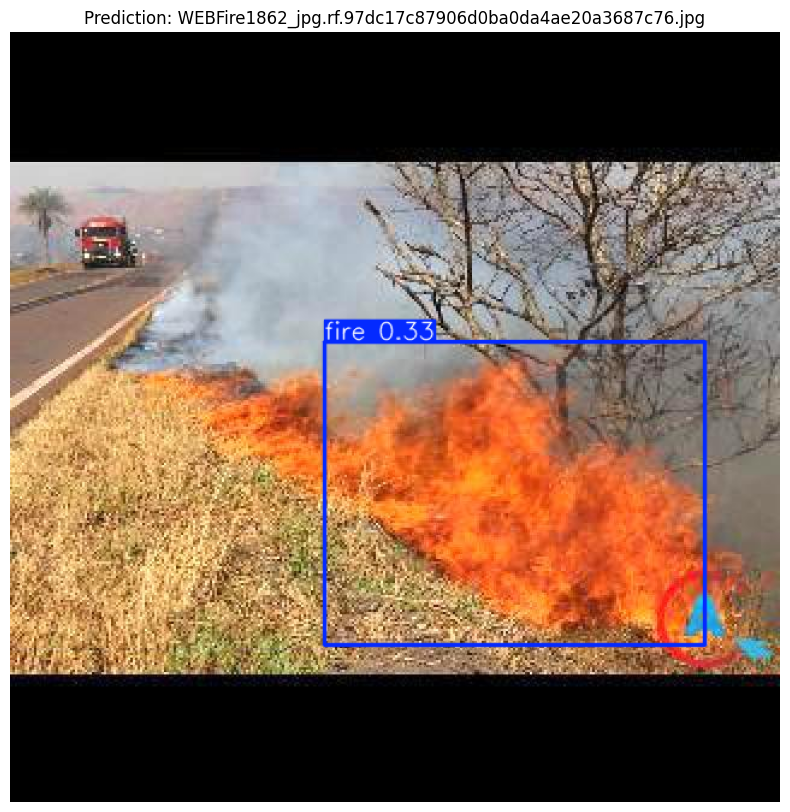


image 1/1 /content/mini_data/train/images/image_40_jpg.rf.14a62bf5c4276b063a5966dc1f2c6828.jpg: 640x640 (no detections), 9.9ms
Speed: 1.7ms preprocess, 9.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


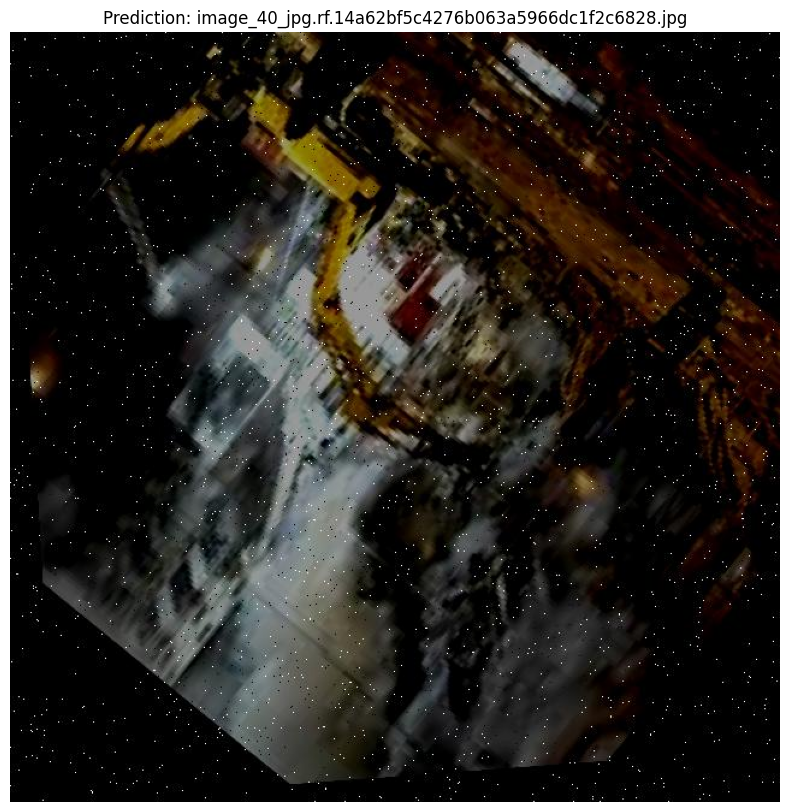


image 1/1 /content/mini_data/train/images/youtube-28_jpg.rf.9deb59e02d3ed32f42c2e9455ba30574.jpg: 640x640 2 fires, 9.1ms
Speed: 1.7ms preprocess, 9.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


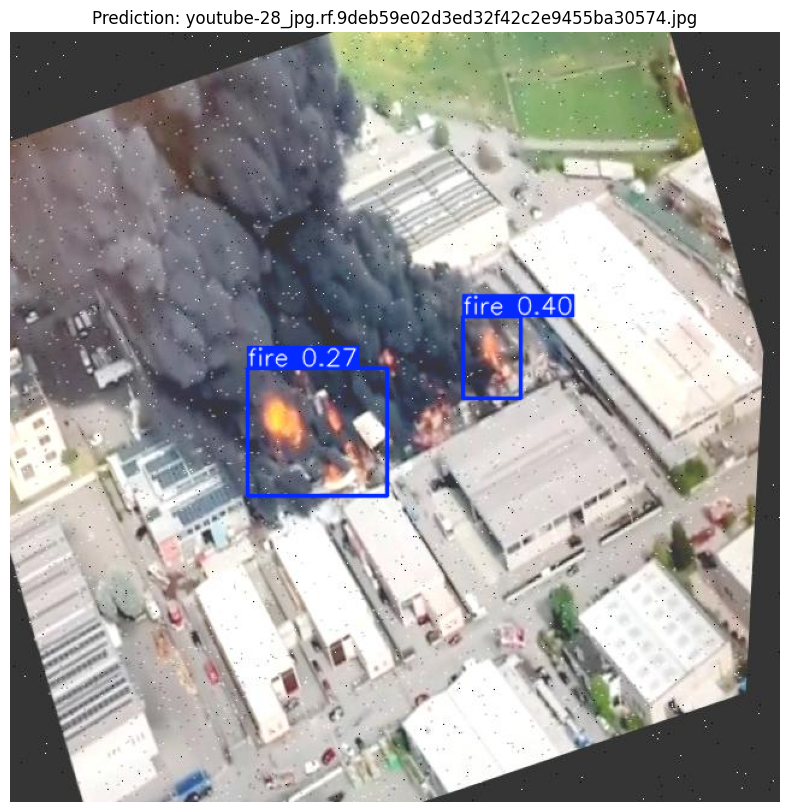

In [12]:
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO
import os

# 1. Load your brand new best model
my_model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

# 2. Grab 3 random images from your mini_data to test
test_path = "/content/mini_data/train/images"
test_images = os.listdir(test_path)[:3] 

for img_name in test_images:
    full_path = os.path.join(test_path, img_name)
    
    # 3. Run Inference
    results = my_model.predict(source=full_path, conf=0.25) # 0.25 confidence threshold
    
    # 4. Plot and Display
    for r in results:
        img_bgr = r.plot() # This adds the boxes and scores to the image
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(10, 10))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(f"Prediction: {img_name}")
        plt.show()